# Lab 03 — Word Representations and Embeddings

Notebook xây dựng co-occurrence representation, huấn luyện Word2Vec và đánh giá embedding bằng similarity, analogy và semantic search.

## 10. Experiment 1 — Word-context representation

Thử nghiệm đầu dùng corpus nhỏ để có thể kiểm tra trực tiếp các count với `window = 1, 2, 5`.

In [1]:
from collections import Counter
from pathlib import Path
import gc
import os
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.decomposition import TruncatedSVD

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'labs').exists():
    REPO_ROOT = REPO_ROOT.parents[1]
sys.path.insert(0, str(REPO_ROOT))

from labs.lab03.cooccurrence import (
    build_cooccurrence_matrix,
    build_vocabulary,
    cosine_similarity,
    load_c4_documents,
    most_similar,
    prepare_sentences,
    tokenize,
    word_similarity,
)

LAB_DIR = REPO_ROOT / 'labs/lab03'
DATA_PATH = LAB_DIR / 'data/c4-train.00000-of-01024-30K.json.gz'
RESULTS_PATH = LAB_DIR / 'results.csv'
DOCUMENT_LIMIT = 10_000
RANDOM_SEED = 42

assert DATA_PATH.exists(), f'Missing dataset: {DATA_PATH}'

In [2]:
toy_sentences = [
    tokenize('the cat eats fish'),
    tokenize('the cat likes milk'),
    tokenize('the dog eats meat'),
    tokenize('the dog likes fish'),
]
toy_vocabulary = build_vocabulary(toy_sentences, min_count=1)
toy_words = [word for word, _ in sorted(toy_vocabulary.items(), key=lambda item: item[1])]

cooccurrence_matrices = {}
cooccurrence_stat_rows = []
cooccurrence_similarity_rows = []
comparison_pairs = [('cat', 'dog'), ('eats', 'likes'), ('cat', 'eats')]

for window in (1, 2, 5):
    matrix = build_cooccurrence_matrix(toy_sentences, toy_vocabulary, window)
    cooccurrence_matrices[window] = matrix
    cooccurrence_stat_rows.append({
        'result_type': 'cooccurrence_stats',
        'window': window,
        'vocabulary_size': len(toy_vocabulary),
        'matrix_rows': matrix.shape[0],
        'matrix_columns': matrix.shape[1],
        'non_zero_values': matrix.nnz,
        'density': matrix.nnz / (matrix.shape[0] * matrix.shape[1]),
    })
    for word_a, word_b in comparison_pairs:
        cooccurrence_similarity_rows.append({
            'result_type': 'cooccurrence_similarity',
            'window': window,
            'word_a': word_a,
            'word_b': word_b,
            'similarity': word_similarity(
                word_a, word_b, matrix, toy_vocabulary
            ),
        })

cooccurrence_stats = pd.DataFrame(cooccurrence_stat_rows)
cooccurrence_similarities = pd.DataFrame(cooccurrence_similarity_rows)
display(cooccurrence_stats)
cooccurrence_similarities.pivot(
    index=['word_a', 'word_b'], columns='window', values='similarity'
)

,result_type,window,vocabulary_size,matrix_rows,matrix_columns,non_zero_values,density
0,cooccurrence_stats,1,8,8,8,20,0.31250
1,cooccurrence_stats,2,8,8,8,32,0.50000
2,cooccurrence_stats,5,8,8,8,38,0.59375


window            1      2      5
word_a word_b                    
cat    dog     1.00  0.875  0.875
       eats    0.00  0.625  0.625
eats   likes   0.75  0.875  0.875

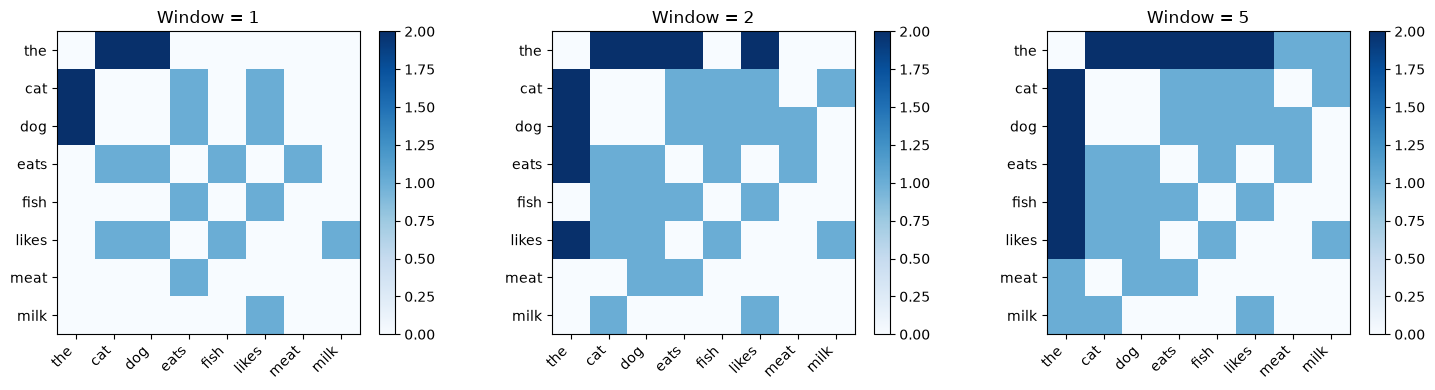

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for window, axis in zip((1, 2, 5), axes):
    dense = cooccurrence_matrices[window].toarray()
    image = axis.imshow(dense, cmap='Blues')
    axis.set_title(f'Window = {window}')
    axis.set_xticks(range(len(toy_words)), toy_words, rotation=45, ha='right')
    axis.set_yticks(range(len(toy_words)), toy_words)
    fig.colorbar(image, ax=axis, fraction=0.046)
plt.tight_layout()
plt.show()

## 11. Core implementation

`cooccurrence.py` tự cài đặt `build_vocabulary`, `build_cooccurrence_matrix`, `cosine_similarity` và `most_similar`. Phần này không dùng Word2Vec.

In [4]:
calculation_corpus = [
    tokenize('the cat eats fish'),
    tokenize('the dog eats fish'),
    tokenize('the cat likes milk'),
    tokenize('the dog likes meat'),
]
calculation_vocab = build_vocabulary(calculation_corpus, min_count=1)
calculation_matrix = build_cooccurrence_matrix(
    calculation_corpus, calculation_vocab, window_size=1
)

assert calculation_matrix[calculation_vocab['cat'], calculation_vocab['the']] == 2
assert calculation_matrix[calculation_vocab['dog'], calculation_vocab['the']] == 2
assert np.isclose(cosine_similarity([1, 2, 1], [2, 4, 2]), 1.0)
assert most_similar('cat', calculation_matrix, calculation_vocab, 1)[0][0] == 'dog'
print('All co-occurrence implementation checks passed.')

All co-occurrence implementation checks passed.


## 12. Từ co-occurrence matrix đến embedding

Vocabulary 100.000 từ tạo ma trận 100.000 × 100.000, tương đương 10 tỷ ô. Ma trận sparse giúp giảm bộ nhớ nhưng số chiều vẫn rất lớn. Có thể dùng giảm chiều để tạo representation dense nhỏ hơn.

In [5]:
svd = TruncatedSVD(n_components=4, random_state=RANDOM_SEED)
toy_dense_embedding = svd.fit_transform(cooccurrence_matrices[2])
dense_neighbors = pd.DataFrame(
    most_similar('cat', toy_dense_embedding, toy_vocabulary, top_k=5),
    columns=['word', 'similarity'],
)
print('Dense embedding shape:', toy_dense_embedding.shape)
dense_neighbors

Dense embedding shape: (8, 4)


,word,similarity
0,dog,0.915054
1,likes,0.744659
2,eats,0.659714
3,meat,0.412484
4,the,0.357310


## 13. Neural Word Embeddings

Word2Vec học dense vector từ nhiệm vụ dự đoán dựa trên context thay vì giữ nguyên ma trận count lớn.

## 14. CBOW

CBOW dùng các từ context để dự đoán target word.

## 15. Skip-gram

Skip-gram dùng target word để dự đoán các context words.

**Trả lời:** CBOW nhận các từ context làm input và dự đoán từ trung tâm làm target. Ngược lại, Skip-gram nhận từ trung tâm làm input và dự đoán các từ context làm target.

## 16. Bài tập prediction — CBOW vs Skip-gram

Các training examples với `window = 1` được trình bày trong `calculations.md`.

## 17. Experiment 2 — Word2Vec

- Corpus: 10.000 documents đầu tiên của C4 30K.
- Baseline: Skip-gram với negative sampling.
- `vector_size = 100`, `window = 5`, `min_count = 2`, `epochs = 10`.
- Seed cố định là 42; dùng tối đa 4 workers.

In [6]:
documents = load_c4_documents(DATA_PATH, limit=DOCUMENT_LIMIT)
sentences = prepare_sentences(documents, max_sentence_length=80)
token_count = sum(map(len, sentences))

corpus_summary = pd.DataFrame([{
    'documents': len(documents),
    'sentences': len(sentences),
    'tokens': token_count,
}])
corpus_summary

,documents,sentences,tokens
0,10000,204298,3636930


In [7]:
WORKERS = max(1, min(4, os.cpu_count() or 1))
model_rows = []

def model_size_bytes(model):
    total = model.wv.vectors.nbytes
    if hasattr(model, 'syn1neg'):
        total += model.syn1neg.nbytes
    return int(total)

def train_word2vec(config, vector_size, window):
    started = time.perf_counter()
    model = Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=2,
        sg=1,
        negative=5,
        epochs=10,
        seed=RANDOM_SEED,
        workers=WORKERS,
    )
    elapsed = time.perf_counter() - started
    row = {
        'result_type': 'word2vec_model',
        'config': config,
        'vector_size': vector_size,
        'window': window,
        'min_count': 2,
        'epochs': 10,
        'objective': 'skip-gram negative sampling',
        'vocabulary_size': len(model.wv),
        'training_time_seconds': elapsed,
        'model_size_bytes': model_size_bytes(model),
    }
    model_rows.append(row)
    return model

baseline_model = train_word2vec('baseline_w5_d100', 100, 5)
pd.DataFrame(model_rows)

,result_type,config,vector_size,window,min_count,epochs,objective,vocabulary_size,training_time_seconds,model_size_bytes
0,word2vec_model,baseline_w5_d100,100,5,2,10,skip-gram negative sampling,54440,29.971016,43552000


## 18. Inspect embeddings

Top-5 của `doctor` được đối chiếu với số lần mỗi từ xuất hiện trong context window 5 quanh `doctor` trong corpus.

Kết quả gồm `physician`, `dentist`, `surgeon`, `veterinarian` và `ophthalmologist`. Đây đều là các nghề y tế hoặc điều trị và thường chia sẻ context như `care`, `health`, `visit` và `medical`. Nhiều từ không đứng trực tiếp gần `doctor`, nên similarity chủ yếu đến từ các context chung trong corpus.

In [8]:
inspect_words = ['doctor', 'hospital', 'patient', 'disease', 'computer', 'football', 'banana']
inspect_rows = []
for word in inspect_words:
    in_vocabulary = word in baseline_model.wv
    inspect_rows.append({
        'word': word,
        'in_vocabulary': in_vocabulary,
        'corpus_count': baseline_model.wv.get_vecattr(word, 'count') if in_vocabulary else 0,
        'vector_norm': float(np.linalg.norm(baseline_model.wv[word])) if in_vocabulary else np.nan,
    })
display(pd.DataFrame(inspect_rows))

doctor_context_counts = Counter()
for sentence in sentences:
    for index, token in enumerate(sentence):
        if token == 'doctor':
            left = max(0, index - 5)
            right = min(len(sentence), index + 6)
            doctor_context_counts.update(
                sentence[position]
                for position in range(left, right)
                if position != index
            )

doctor_neighbor_rows = []
for rank, (word, similarity) in enumerate(
    baseline_model.wv.most_similar('doctor', topn=5), start=1
):
    doctor_neighbor_rows.append({
        'result_type': 'doctor_neighbor',
        'rank': rank,
        'query': 'doctor',
        'word': word,
        'similarity': similarity,
        'corpus_context_count': doctor_context_counts[word],
    })
doctor_neighbors = pd.DataFrame(doctor_neighbor_rows)
doctor_neighbors

,word,in_vocabulary,corpus_count,vector_norm
0,doctor,True,263,3.647328
1,hospital,True,356,3.958255
2,patient,True,320,3.565354
3,disease,True,368,4.318180
4,computer,True,622,3.842070
5,football,True,575,5.359259
6,banana,True,42,2.886619


,result_type,rank,query,word,similarity,corpus_context_count
0,doctor_neighbor,1,doctor,physician,0.748929,0
1,doctor_neighbor,2,doctor,dentist,0.741220,1
2,doctor_neighbor,3,doctor,surgeon,0.731898,2
3,doctor_neighbor,4,doctor,veterinarian,0.713972,0
4,doctor_neighbor,5,doctor,ophthalmologist,0.702674,0


## 19. Experiment 3 — Context window

Ba model giữ nguyên dimension 100 và chỉ thay đổi `window = 2, 5, 10`.

In [9]:
def safe_similarity(model, word_a, word_b):
    if word_a not in model.wv or word_b not in model.wv:
        return np.nan
    return float(model.wv.similarity(word_a, word_b))

window_pairs = [('doctor', 'physician'), ('doctor', 'hospital'), ('cat', 'dog')]
window_similarity_rows = []

for window, model in [(5, baseline_model)]:
    for word_a, word_b in window_pairs:
        window_similarity_rows.append({
            'result_type': 'window_similarity',
            'window': window,
            'vector_size': 100,
            'word_a': word_a,
            'word_b': word_b,
            'similarity': safe_similarity(model, word_a, word_b),
        })

for window in (2, 10):
    model = train_word2vec(f'window_{window}_d100', 100, window)
    for word_a, word_b in window_pairs:
        window_similarity_rows.append({
            'result_type': 'window_similarity',
            'window': window,
            'vector_size': 100,
            'word_a': word_a,
            'word_b': word_b,
            'similarity': safe_similarity(model, word_a, word_b),
        })
    del model
    gc.collect()

window_results = pd.DataFrame(window_similarity_rows)
window_results.pivot(index=['word_a', 'word_b'], columns='window', values='similarity')

window                  2         5         10
word_a word_b                                 
cat    dog        0.619126  0.594239  0.526493
doctor hospital   0.555911  0.569727  0.527262
       physician  0.732310  0.748929  0.729380

Window lớn hơn không luôn tốt hơn. `doctor–physician` và `doctor–hospital` cao nhất ở window 5, còn `cat–dog` cao nhất ở window 2. Cả ba cặp đều giảm ở window 10, cho thấy context rộng hơn có thể thêm nhiễu.

## 20. Experiment 4 — Embedding dimension

So sánh dimension 50, 100 và 300 với cùng `window = 5`. Downstream task đơn giản là phân loại từ theo centroid của bốn nhóm: medical, technology, sport và food.

In [10]:
word_categories = {
    'medical': ['doctor', 'physician', 'hospital', 'patient', 'disease'],
    'technology': ['computer', 'software', 'internet', 'data', 'technology'],
    'sport': ['football', 'soccer', 'basketball', 'team', 'player'],
    'food': ['banana', 'apple', 'orange', 'fruit', 'food'],
}

def category_accuracy(model):
    examples = [
        (word, label)
        for label, words in word_categories.items()
        for word in words
        if word in model.wv
    ]
    correct = 0
    for word, expected in examples:
        centroids = {}
        for label, words in word_categories.items():
            vectors = [
                model.wv[item]
                for item in words
                if item in model.wv and item != word
            ]
            if vectors:
                centroids[label] = np.mean(vectors, axis=0)
        predicted = max(
            centroids,
            key=lambda label: cosine_similarity(model.wv[word], centroids[label]),
        )
        correct += predicted == expected
    return correct / len(examples) if examples else np.nan

def analogy_top_word(model):
    required = {'king', 'woman', 'man'}
    if not required.issubset(model.wv.key_to_index):
        return None
    return model.wv.most_similar(
        positive=['king', 'woman'], negative=['man'], topn=1
    )[0][0]

dimension_rows = []
baseline_info = next(row for row in model_rows if row['config'] == 'baseline_w5_d100')
dimension_rows.append({
    'result_type': 'dimension_evaluation',
    'vector_size': 100,
    'window': 5,
    'training_time_seconds': baseline_info['training_time_seconds'],
    'model_size_bytes': baseline_info['model_size_bytes'],
    'doctor_physician_similarity': safe_similarity(baseline_model, 'doctor', 'physician'),
    'analogy_top_word': analogy_top_word(baseline_model),
    'category_accuracy': category_accuracy(baseline_model),
})

for dimension in (50, 300):
    model = train_word2vec(f'dimension_{dimension}_w5', dimension, 5)
    info = model_rows[-1]
    dimension_rows.append({
        'result_type': 'dimension_evaluation',
        'vector_size': dimension,
        'window': 5,
        'training_time_seconds': info['training_time_seconds'],
        'model_size_bytes': info['model_size_bytes'],
        'doctor_physician_similarity': safe_similarity(model, 'doctor', 'physician'),
        'analogy_top_word': analogy_top_word(model),
        'category_accuracy': category_accuracy(model),
    })
    del model
    gc.collect()

dimension_results = pd.DataFrame(dimension_rows).sort_values('vector_size')
dimension_results

,result_type,vector_size,window,training_time_seconds,model_size_bytes,doctor_physician_similarity,analogy_top_word,category_accuracy
1,dimension_evaluation,50,5,28.916831,21776000,0.813409,queen,1.0
0,dimension_evaluation,100,5,29.971016,43552000,0.748929,queen,1.0
2,dimension_evaluation,300,5,58.786978,130656000,0.565914,queen,1.0


Model 50, 100 và 300 chiều lần lượt chiếm khoảng 21,78 MB, 43,55 MB và 130,66 MB. Cả ba đều đạt accuracy 1,0 ở bài phân loại nhỏ và trả về `queen` cho analogy, nhưng similarity `doctor–physician` lại giảm từ 0,8134 xuống 0,7489 và 0,5659. Dimension lớn hơn tốn thêm tài nguyên nhưng không tự động tốt hơn.

## 21. Evaluation — Word similarity

Các cặp được xếp hạng theo cosine similarity và so sánh với thứ tự dự đoán trực giác.

Model xếp `doctor–physician` cao nhất và `computer–banana` thấp nhất như dự đoán. Điểm bất ngờ nhỏ là `king–queen` đứng trên `car–automobile`, dù hai score khá gần nhau: 0,6808 và 0,6701.

In [11]:
similarity_pairs = [
    ('doctor', 'physician', 1),
    ('car', 'automobile', 2),
    ('king', 'queen', 3),
    ('cat', 'dog', 4),
    ('computer', 'banana', 5),
]
similarity_rows = []
for word_a, word_b, intuition_rank in similarity_pairs:
    similarity_rows.append({
        'result_type': 'word_similarity',
        'word_a': word_a,
        'word_b': word_b,
        'intuition_rank': intuition_rank,
        'similarity': safe_similarity(baseline_model, word_a, word_b),
    })
similarity_results = pd.DataFrame(similarity_rows).sort_values(
    'similarity', ascending=False
).reset_index(drop=True)
similarity_results['model_rank'] = np.arange(1, len(similarity_results) + 1)
similarity_results

,result_type,word_a,word_b,intuition_rank,similarity,model_rank
0,word_similarity,doctor,physician,1,0.748929,1
1,word_similarity,king,queen,3,0.680830,2
2,word_similarity,car,automobile,2,0.670128,3
3,word_similarity,cat,dog,4,0.594239,4
4,word_similarity,computer,banana,5,0.068576,5


## 22. Evaluation — Word analogy

Vector arithmetic biểu diễn một hướng quan hệ đã xuất hiện trong vector space. Kết quả không có nghĩa model hiểu quan hệ giống con người.

Với `king - man + woman`, model trả về `queen` ở hạng 1 với similarity 0,6104. Điều này cho thấy hướng vector của quan hệ giới tính và hoàng gia được phản ánh trong không gian embedding.

In [12]:
analogy_rows = []
analogy_candidates = baseline_model.wv.most_similar(
    positive=['king', 'woman'], negative=['man'], topn=5
)
for rank, (word, similarity) in enumerate(analogy_candidates, start=1):
    analogy_rows.append({
        'result_type': 'analogy',
        'positive': 'king,woman',
        'negative': 'man',
        'rank': rank,
        'word': word,
        'similarity': similarity,
        'expected': 'queen',
        'correct': word == 'queen',
    })
analogy_results = pd.DataFrame(analogy_rows)
analogy_results

,result_type,positive,negative,rank,word,similarity,expected,correct
0,analogy,"king,woman",man,1,queen,0.610365,queen,True
1,analogy,"king,woman",man,2,comforter,0.490562,queen,False
2,analogy,"king,woman",man,3,cal,0.486874,queen,False
3,analogy,"king,woman",man,4,robes,0.482856,queen,False
4,analogy,"king,woman",man,5,duchess,0.480769,queen,False


## 23. Bài tập tính analogy

Phép tính vector giả định và phần giải thích nằm trong `calculations.md`.

## 24. Application — Semantic Search

Query và document được biểu diễn bằng trung bình Word2Vec vectors. Thử nghiệm tìm Top-5 trong 2.000 documents đầu tiên.

Các kết quả đầu đều liên quan đến bệnh nhân, điều trị, ung thư, gây mê hoặc chăm sóc sức khỏe, nên semantic search phù hợp với query `medical treatment`.

In [13]:
def average_embedding(tokens, model, max_tokens=200):
    vectors = [model.wv[token] for token in tokens[:max_tokens] if token in model.wv]
    if not vectors:
        return None
    return np.mean(vectors, axis=0)

query = 'medical treatment'
query_vector = average_embedding(tokenize(query), baseline_model)
assert query_vector is not None

search_rows = []
for document_id, document in enumerate(documents[:2_000]):
    vector = average_embedding(tokenize(document), baseline_model)
    if vector is None:
        continue
    search_rows.append({
        'document_id': document_id,
        'similarity': cosine_similarity(query_vector, vector),
        'snippet': ' '.join(document.replace('\n', ' ').split())[:220],
    })

semantic_search = pd.DataFrame(search_rows).nlargest(5, 'similarity').reset_index(drop=True)
semantic_search['rank'] = np.arange(1, len(semantic_search) + 1)
semantic_search['result_type'] = 'semantic_search'
semantic_search['query'] = query
semantic_search[['rank', 'document_id', 'similarity', 'snippet']]

,rank,document_id,similarity,snippet
0,1,280,0.779381,A phase II pilot study to evaluate use of intr...
1,2,1516,0.722604,"MONDAY, Nov. 2, 2009 (HealthDay News) -- The l..."
2,3,1583,0.713083,Dr. Bethea speaks of a minimally invasive appr...
3,4,1229,0.711914,Anesthesia is administered to patients who are...
4,5,129,0.711876,Bridging science and policy decision-making. T...


## 25. Error analysis

Ba quan hệ hợp lý và ba neighbor bất ngờ của `doctor` được chọn từ output thực tế. Phân tích chi tiết nằm trong `error_analysis.md`.

In [14]:
expected_pairs = [('doctor', 'physician'), ('doctor', 'hospital'), ('cat', 'dog')]
expected_medical = {
    'doctor', 'doctors', 'physician', 'physicians', 'hospital', 'patient',
    'patients', 'nurse', 'nurses', 'medical', 'medicine', 'disease',
    'treatment', 'clinical', 'surgeon', 'healthcare',
}
unexpected_neighbors = [
    (word, score)
    for word, score in baseline_model.wv.most_similar('doctor', topn=50)
    if word not in expected_medical
][:3]

error_rows = []
for word_a, word_b in expected_pairs:
    error_rows.append({
        'result_type': 'error_analysis',
        'case_type': 'expected',
        'word_a': word_a,
        'word_b': word_b,
        'similarity': safe_similarity(baseline_model, word_a, word_b),
        'word_a_count': baseline_model.wv.get_vecattr(word_a, 'count'),
        'word_b_count': baseline_model.wv.get_vecattr(word_b, 'count'),
        'context_count_with_doctor': doctor_context_counts[word_b] if word_a == 'doctor' else np.nan,
    })
for word, score in unexpected_neighbors:
    error_rows.append({
        'result_type': 'error_analysis',
        'case_type': 'unexpected',
        'word_a': 'doctor',
        'word_b': word,
        'similarity': score,
        'word_a_count': baseline_model.wv.get_vecattr('doctor', 'count'),
        'word_b_count': baseline_model.wv.get_vecattr(word, 'count'),
        'context_count_with_doctor': doctor_context_counts[word],
    })
error_cases = pd.DataFrame(error_rows)
assert len(error_cases[error_cases['case_type'] == 'expected']) == 3
assert len(error_cases[error_cases['case_type'] == 'unexpected']) == 3
error_cases

,result_type,case_type,word_a,word_b,similarity,word_a_count,word_b_count,context_count_with_doctor
0,error_analysis,expected,doctor,physician,0.748929,263,86,0.0
1,error_analysis,expected,doctor,hospital,0.569727,263,356,1.0
2,error_analysis,expected,cat,dog,0.594239,218,428,NaN
3,error_analysis,unexpected,doctor,dentist,0.741220,263,49,1.0
4,error_analysis,unexpected,doctor,veterinarian,0.713972,263,20,0.0
5,error_analysis,unexpected,doctor,ophthalmologist,0.702674,263,10,0.0


## 26. Polysemy

Static Word2Vec chỉ có một vector cho `bank`, nên context ngân hàng và bờ sông bị trộn trong cùng representation. Đây là lý do cần contextual embedding.

## 27. Reflection — Từ Word2Vec đến Transformer

Bảng so sánh representation và câu trả lời về `bank` nằm trong `reflection.md`.

## 28. AI policy

AI assistance statement được ghi trong `README.md`.

## 29. Individual learning check

1. Distributional hypothesis: từ xuất hiện trong context giống nhau thường có nghĩa gần nhau.
2. `doctor` và `physician` có thể gần nhau vì chúng thường đi cùng các từ về bệnh nhân và điều trị.
3. CBOW dùng context dự đoán target; Skip-gram dùng target dự đoán context.
4. Window lớn thu được context rộng hơn nhưng cũng có thể thêm nhiễu.
5. Word2Vec không phân biệt hai nghĩa của `bank` vì mỗi từ chỉ có một vector.
6. TF-IDF biểu diễn mức quan trọng của từ trong document, không học một dense vector semantic riêng cho mỗi từ.

## Xuất `results.csv`

File kết quả gom các thống kê, hyperparameter experiments, similarity, analogy, semantic search và error-analysis cases.

In [15]:
results = pd.concat(
    [
        cooccurrence_stats,
        cooccurrence_similarities,
        pd.DataFrame(model_rows),
        window_results,
        dimension_results,
        similarity_results,
        doctor_neighbors,
        analogy_results,
        semantic_search,
        error_cases,
    ],
    ignore_index=True,
    sort=False,
)
results.to_csv(RESULTS_PATH, index=False, encoding='utf-8')
print(f'Wrote {len(results)} rows to {RESULTS_PATH}')
results['result_type'].value_counts()

Wrote 55 rows to D:\Project\NLP-2025\NLP-Labs\labs\lab03\results.csv


result_type
cooccurrence_similarity    9
window_similarity          9
error_analysis             6
word2vec_model             5
word_similarity            5
doctor_neighbor            5
analogy                    5
semantic_search            5
cooccurrence_stats         3
dimension_evaluation       3
Name: count, dtype: int64